# Phase 4 — Retrieval-Augmented Denial Prediction
**CS6140 · From Codes to Context · Sruthilaya**

Phase 4 asks: can *retrieving analogous past claims* improve denial prediction
over a structured-only model, and can we do it **without fooling ourselves**?

This phase is self-contained: it uses a controlled synthetic claims generator
with a documented, *learnable* fault-injection denial rule (calibrated to the
~19% CMS ACA 2024 denial rate). Because we own the labeling rule, we can do
things you cannot do with real labels — measure the recoverable-signal ceiling,
quantify how label noise degrades results, and show a reviewer *why* a claim is
risky. Everything routes through the shared `ClaimRecord` schema and
`shared/utils/eval.py`, so results are comparable to Phases 1–3.

## 1. Data & injected labels

In [1]:
import sys, json
sys.path.insert(0, r"d:/Sruthi/LevelUP/NU/ML/Project/claim-denial-prediction")
import pandas as pd
from phase4_rag_agentic.src.data_gen import generate_claims
from phase4_rag_agentic.src.labeling import label_claims

gen = generate_claims(n=40_000, seed=42)
res = label_claims(gen.frame, target_prevalence=0.19, seed=42)
print(f"realized denial prevalence: {res.realized_prevalence:.4f} (target 0.19)")
print(f"calibrated intercept: {res.intercept:.3f}\n")
pd.Series(res.driver_prevalence).sort_values(ascending=False).rename("trip rate").to_frame()


realized denial prevalence: 0.1907 (target 0.19)
calibrated intercept: -3.101



,trip rate
out_of_network,0.209825
medical_necessity,0.121450
billing_anomaly,0.101550
missing_prior_auth,0.068225
untimely_filing,0.042400


The denial rule is a log-additive risk model over five real denial drivers
(untimely filing, missing prior authorization, medical necessity, out-of-network,
billing anomaly) plus a **latent per-provider denial propensity**. The intercept
is auto-calibrated by bisection so realized prevalence matches the target.

In [2]:
denied = res.frame[res.frame.denied == 1]
denied["reason_code"].value_counts().rename("denied claims").to_frame()

,denied claims
reason_code,
No dominant driver (baseline payer risk),1608
CO-50 Non-covered: not deemed medically necessary,1531
CO-197 Precertification/authorization absent,1505
CO-242 Services not provided by network provider,1432
CO-29 Untimely filing: submitted after payer window,1119
CO-45 Charge exceeds fee schedule / documentation,434


## 2. Leakage-safe methodology & the ablation

- **Temporal split** — train on earlier submission dates, test on later ones
  (retrieval at inference only ever sees the past).
- **Index over training claims only**; a training claim **excludes itself** from
  its neighbours.
- We also train a deliberately **leaky** variant (index contains the test claims)
  to show how a common mistake inflates the score.

Headline numbers below are the canonical run from `scripts/run_phase4.py`
(40k claims).

In [3]:
m = json.load(open(r"d:/Sruthi/LevelUP/NU/ML/Project/claim-denial-prediction/phase4_rag_agentic/artifacts/metrics.json"))
rows = []
for key, label in [("B_structured_xgb","Structured XGBoost"),
                   ("B_retrieval_augmented","+ Retrieval features"),
                   ("B_leaky_index_has_test","Leaky index (INVALID)")]:
    if key in m:
        r = m[key]
        rows.append([label, r["auroc"], r["f1"], r["precision"], r["recall"]])
tab = pd.DataFrame(rows, columns=["model","AUROC","F1","precision","recall"])
print("oracle ceiling AUROC:", round(m["oracle_ceiling_auroc"],4),
      "| test prevalence:", round(m["test_prevalence"],3))
tab.round(4)

oracle ceiling AUROC: 0.8686 | test prevalence: 0.237


,model,AUROC,F1,precision,recall
0,Structured XGBoost,0.7423,0.4173,0.6228,0.3138
1,+ Retrieval features,0.7656,0.4480,0.6192,0.3509
2,Leaky index (INVALID),0.9730,0.8286,0.8390,0.8184


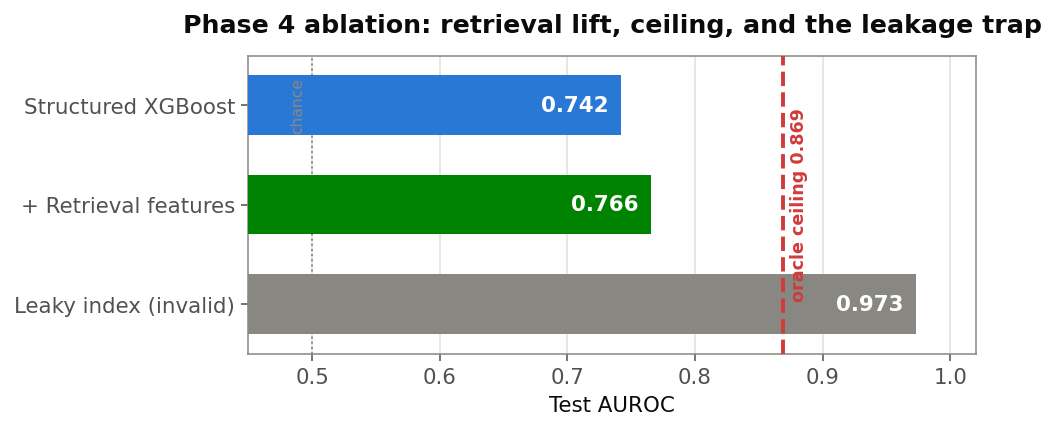

In [4]:
from IPython.display import Image, display
FIG = r"d:/Sruthi/LevelUP/NU/ML/Project/claim-denial-prediction/phase4_rag_agentic/artifacts/figures"
display(Image(FIG + "/ablation_auroc.png"))

The structured model already reaches AUROC ≈ 0.74 — far above the
prototype's near-chance 0.53 — because the injected labels are genuinely
learnable. Retrieval features add a real lift, and the leaky index balloons to
0.97: the number you would wrongly report if you built the FAISS index over the
whole dataset.

**Why retrieval helps:** the classifier never sees `provider_id`; the retrieval
embedding does. So retrieval features recover the latent per-provider denial
propensity the flat model is blind to. SHAP confirms it — the top feature is a
retrieval feature.

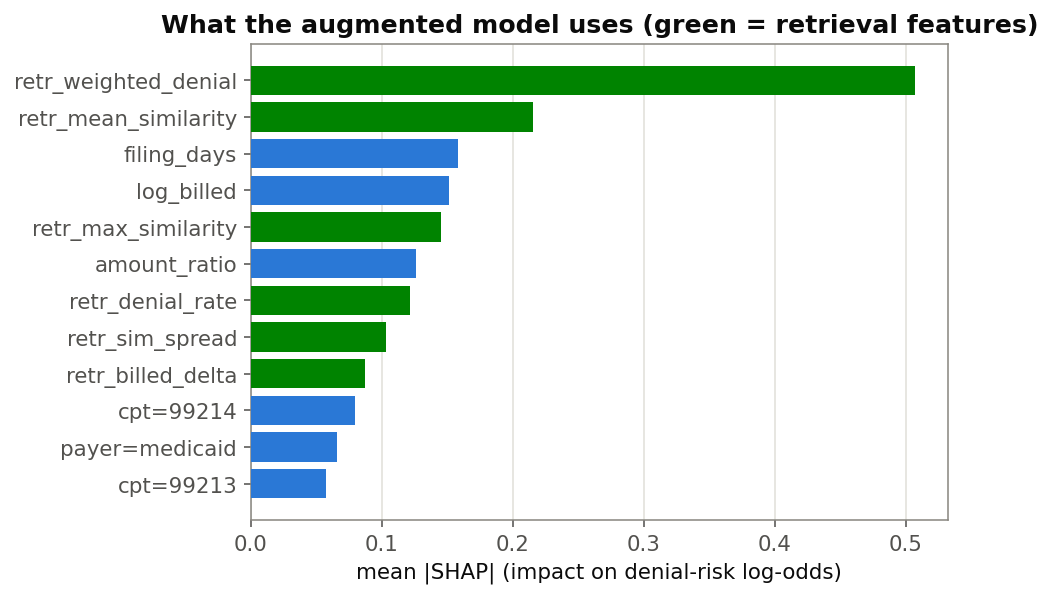

In [5]:
display(Image(FIG + "/shap_bar.png"))

## 3. Calibration & cost-sensitive operating point

cost-optimal threshold 0.07 -> $28.84/claim, saves $658,840 vs filing no appeals


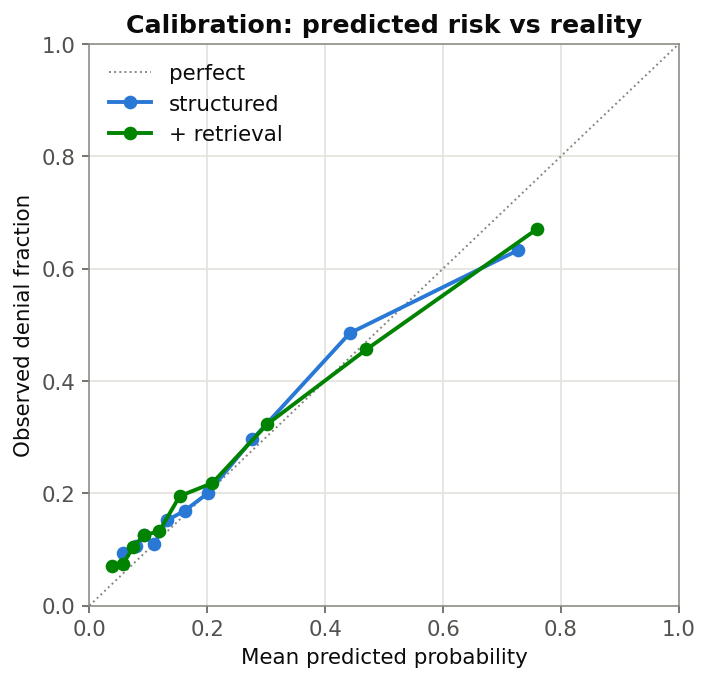

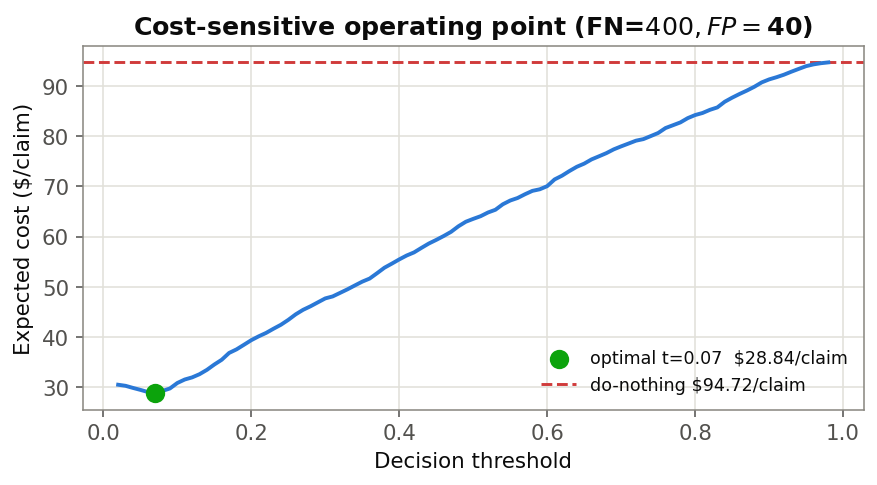

In [6]:
cop = m["cost_operating_point"]
print(f"cost-optimal threshold {cop['threshold']:.2f} -> "
      f"${cop['cost_per_claim']:.2f}/claim, "
      f"saves ${cop['savings_vs_do_nothing']:,.0f} vs filing no appeals")
display(Image(FIG + "/calibration.png"))
display(Image(FIG + "/cost_curve.png"))

## 4. Feedback #1 — stress-testing the injected labels

Because we own the rule, we can quantify exactly how noisy labels hurt: flip a
growing fraction of labels and watch AUROC decay toward chance. The model also
*recovers the rule* — each named driver raises predicted risk, and predicted
risk ranks with the latent true probability (Spearman below).

In [7]:
print("recover-the-rule Spearman:",
      round(m["recover_the_rule"]["rank_agreement_spearman"],3))
lift = m["recover_the_rule"]["driver_risk_lift"]
pd.DataFrame({k: {"risk if driver present": round(v[0],3),
                  "risk if absent": round(v[1],3)} for k,v in lift.items()}).T

recover-the-rule Spearman: 0.667


,risk if driver present,risk if absent
untimely_filing,0.615,0.171
missing_prior_auth,0.333,0.220
medical_necessity,0.422,0.201
out_of_network,0.233,0.226


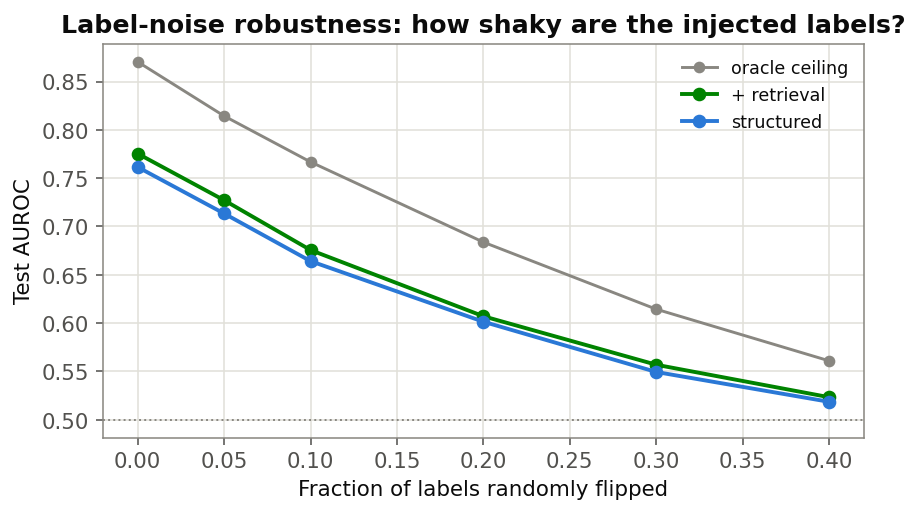

In [8]:
display(Image(FIG + "/noise_sweep.png"))

## 5. Feedback #2 — feature harmonization / population shift

The cross-phase ablation is only valid if populations are comparable. This PSI/KS
report runs between any two claim frames; here it runs on Phase 4's own temporal
train/test split, which genuinely drifts because late-filed (denial-prone) claims
land in the later window. The same call harmonizes Phase 4 vs the Phase 1/2
Kaggle frame at integration time.

In [9]:
from phase4_rag_agentic.src.harmonization import population_shift_report
from phase4_rag_agentic.src.pipeline import _temporal_split
tr, te = _temporal_split(res.frame)
population_shift_report(tr, te)

,feature,type,psi,ks_stat,ks_pvalue,drift
0,billed_amount,numeric,0.001286,0.008633,6.278685e-01,negligible
1,filing_days,numeric,0.194571,0.162467,1.927250e-173,moderate
2,insurance_type,categorical,0.004385,NaN,NaN,negligible
3,cpt_code,categorical,0.000960,NaN,NaN,negligible
4,dx_category,categorical,0.000443,NaN,NaN,negligible
5,denial_prevalence,label,NaN,NaN,NaN,0.175 -> 0.237


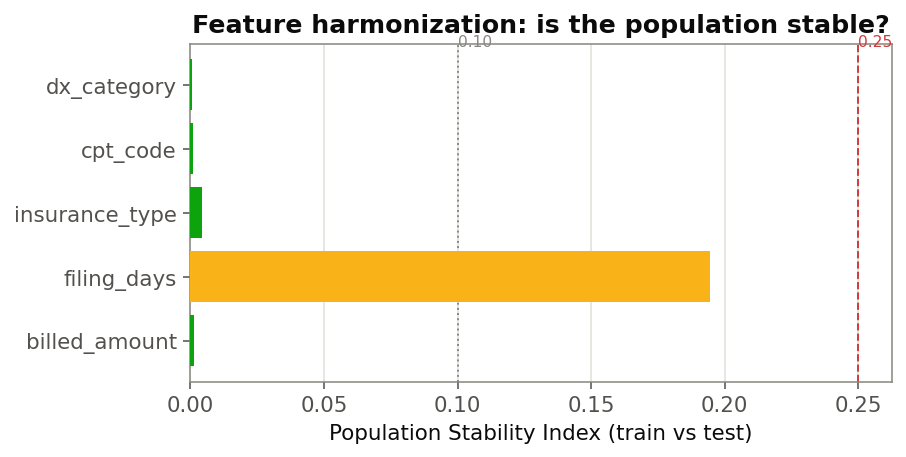

In [10]:
display(Image(FIG + "/harmonization_psi.png"))

## 6. Decision support — the product

Not "73% denial" but *"73% — and the most similar past claims from this provider
were denied for missing prior authorization; confirm the auth is on file."*
Probability comes from the calibrated model; the rationale is composed from the
retrieved evidence (a real LLM if an API key is set, a deterministic fallback
otherwise).

In [11]:
import pickle
from types import SimpleNamespace
from phase4_rag_agentic.src.features import RetrievalFeaturizer
from phase4_rag_agentic.src.retriever import ClaimRetriever
from phase4_rag_agentic.src.data_gen import row_to_claim
from phase4_rag_agentic.src.llm_demo import explain_claim

ART = r"d:/Sruthi/LevelUP/NU/ML/Project/claim-denial-prediction/phase4_rag_agentic/artifacts"
b = pickle.load(open(ART + "/bundle.pkl","rb"))
rtr = ClaimRetriever.load(ART + "/claims_index.faiss")
art = SimpleNamespace(encoder=b["encoder"], model_augmented=b["model_augmented"],
    retriever=rtr, featurizer=RetrievalFeaturizer(rtr, k=b["k"]),
    cost_operating_point=b["cost_operating_point"])
test = pd.read_parquet(ART + "/test_predictions.parquet")
row = test.sort_values("prob_augmented", ascending=False).iloc[0]
ds = explain_claim(art, row_to_claim(row))
print(f"Claim {ds.claim_id}: {ds.denial_probability:.0%} denial risk [{ds.risk_band}]")
print("Action:", ds.suggested_action)
print("Why:", ds.rationale)
pd.DataFrame([{ "claim": e.claim.claim_id, "sim": round(e.similarity,3),
  "provider": e.claim.provider_id, "cpt": e.claim.cpt_code,
  "outcome": "DENIED" if e.claim.denied else "paid",
  "reason": e.claim.reason_code or ""} for e in ds.evidence])

Claim CLM-0014960: 98% denial risk [HIGH]
Action: Escalate: submission is near/over the payer's timely-filing window.
Why: Model estimates a 98% denial risk (HIGH). 8 of the 10 most similar historical claims were denied. The closest match (similarity 0.92) came from provider prov-030. The neighbourhood is dominated by claims that share this claim's billing profile and provider, and the retrieval features raised the risk above what the structured fields alone imply.


,claim,sim,provider,cpt,outcome,reason
0,CLM-0033661,0.919,prov-030,80053,DENIED,CO-29 Untimely filing: submitted after payer w...
1,CLM-0026426,0.909,prov-030,80053,DENIED,CO-29 Untimely filing: submitted after payer w...
2,CLM-0013456,0.857,prov-030,93000,DENIED,CO-29 Untimely filing: submitted after payer w...
3,CLM-0036668,0.844,prov-030,99214,paid,
4,CLM-0026856,0.843,prov-030,80053,DENIED,CO-29 Untimely filing: submitted after payer w...
5,CLM-0019516,0.833,prov-030,99214,DENIED,CO-29 Untimely filing: submitted after payer w...
6,CLM-0036304,0.805,prov-030,99213,DENIED,CO-29 Untimely filing: submitted after payer w...
7,CLM-0038117,0.797,prov-056,99214,paid,
8,CLM-0028478,0.793,prov-025,99213,DENIED,CO-29 Untimely filing: submitted after payer w...
9,CLM-0037997,0.791,prov-035,99214,DENIED,CO-29 Untimely filing: submitted after payer w...


## 7. Reproduce & run the demo
```bash
pip install -e .                         # core stack
python scripts/run_phase4.py             # trains, writes metrics + figures
streamlit run mlops_platform/demo/app.py # interactive decision-support demo
```
faiss and LLM SDKs are optional; a numpy retrieval backend and a mock rationale
cover their absence, so everything is reproducible with no external services.